In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [118]:
df = pd.read_csv(
    "/home/wieger/Documents/Research/Omnisketch/omni/output/pointQueries/CAIDA/results_Test_two_LHS_CAIDA_2024-01-19 11:36:23_Rep2.csv"
                )

df = pd.read_csv("/home/wieger/Documents/Research/Omnisketch/omni/output/pointQueries/CAIDA/results_Test_two_LHS_CAIDA_2024-01-19 11:31:21_Rep2.csv")

In [119]:
def add_condition(df):
    df['condition'] = df['numPredicates']*3*31*32*32/(0.001*df['RAM'])
    df['satCondition'] = ((df['intersectionSizeOfR']/df['unionSizeOfR']) >= df['condition'])
    return df

In [120]:
def preprocess(df):
    df = add_condition(df)
    df['RAM (MB)'] = df['RAM']/(8e6)
    df['UsedRAM'] = df['memUsageSynopsis']/(8e6)
    return df

In [121]:
df = preprocess(df)

In [122]:
df.columns


Index(['repetition', 'totalStreamSize', 'noiseUpdates',
       'streamSizeAfterDeletes', 'numAttributes', 'memUsageDataset', 'RAM',
       'setting', 'sampleType', 'Avg Update Time', 'memUsageSynopsis',
       'parameters', 'numAttributesInWorkload', 'queryID', 'numPredicates',
       'exactAnswer', 'estimate', 'absError', 'relError', 'epsError',
       'withinThreshold', 'estTime', 'queryText', 'intersectionSizeOfR',
       'unionSizeOfR', 'meanQueryTime', 'condition', 'satCondition',
       'RAM (MB)', 'UsedRAM'],
      dtype='object')

In [123]:
df_kmin = df[df['sampleType'] != 'Kmin']
df_kmin['estTime'].unique()

array([1, 0])

In [124]:
df_kmin['meanQueryTime'].value_counts()

16    1000
14    1000
19    1000
27    1000
32    1000
49    1000
Name: meanQueryTime, dtype: int64

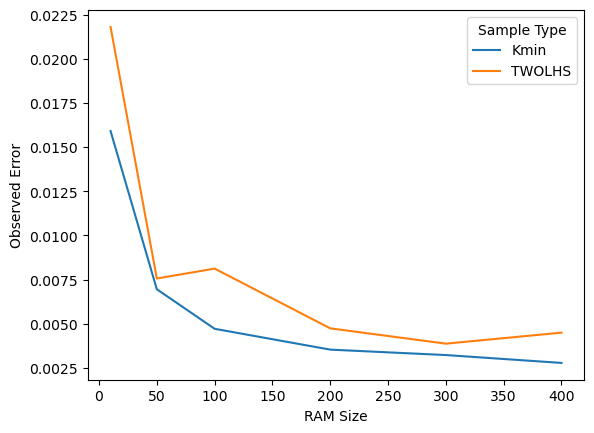

In [125]:
def plot_obs_error(df, x_):
    df_subset = df[['sampleType', 'RAM (MB)', 'epsError']]

    # Group by 'sampleType' and 'RAM' and calculate the mean observed error for each group
    grouped_df = df_subset.groupby(['sampleType', 'RAM (MB)']).mean().reset_index()

    # Plot a line for each 'sampleType'
    for sample_type, group in grouped_df.groupby('sampleType'):
        plt.plot(group['RAM (MB)'], group['epsError'], label=sample_type)

    # Add labels and legend
    plt.xlabel('RAM Size')
    plt.ylabel('Observed Error')
    plt.legend(title='Sample Type')

    # Show the plot
    plt.show()
plot_obs_error(df, 'absError')

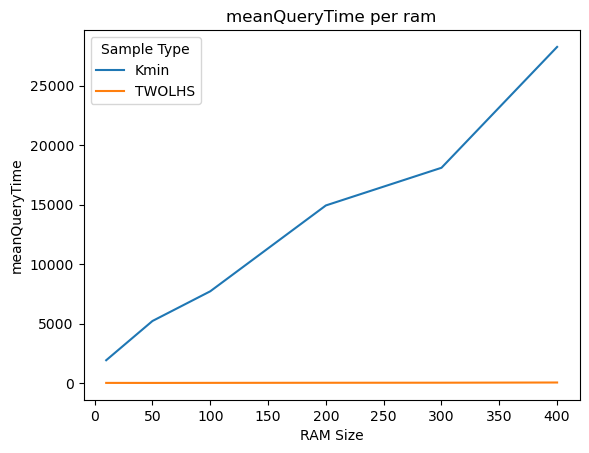

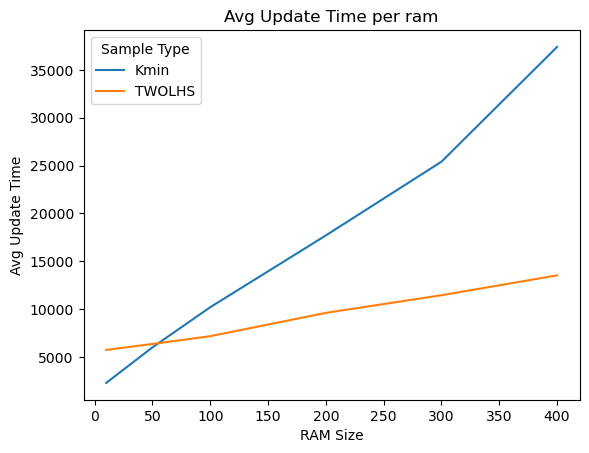

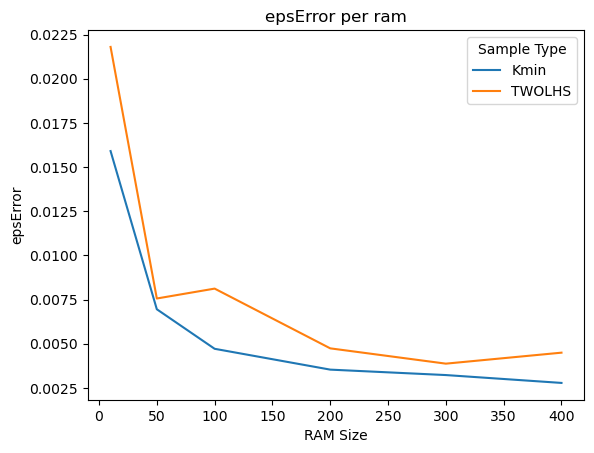

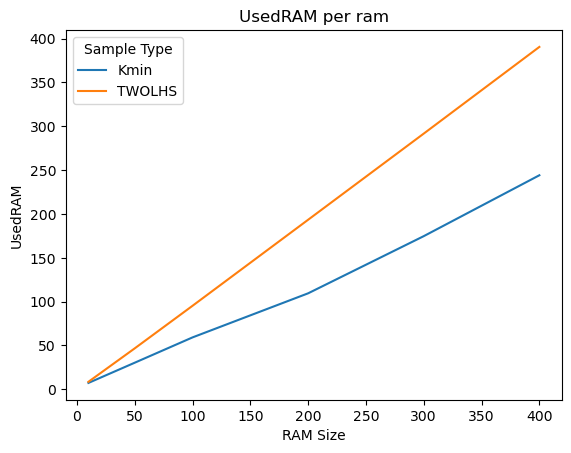

In [126]:
def plot_obs_error(df, x_):
    df_subset = df[['sampleType', 'RAM (MB)', x_]]

    # Group by 'sampleType' and 'RAM' and calculate the mean observed error for each group
    grouped_df = df_subset.groupby(['sampleType', 'RAM (MB)']).mean().reset_index()

    # Plot a line for each 'sampleType'
    for sample_type, group in grouped_df.groupby('sampleType'):
        plt.plot(group['RAM (MB)'], group[x_], label=sample_type)

    # Add labels and legend
    plt.xlabel('RAM Size')
    plt.ylabel(x_)
    plt.title("{} per ram".format(x_))
    plt.legend(title='Sample Type')

    # Show the plot
    plt.show()
plot_obs_error(df, 'meanQueryTime')
plot_obs_error(df, 'Avg Update Time')
plot_obs_error(df, 'epsError')
plot_obs_error(df, 'UsedRAM')

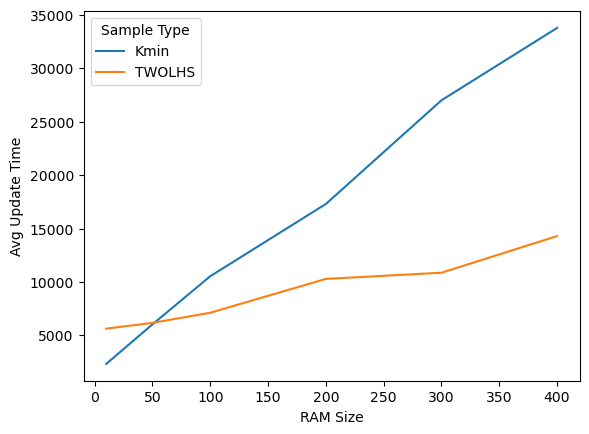

In [33]:
def plot_obs_error(df, x_):
    df_subset = df[['sampleType', 'RAM', 'Avg Update Time']]

    # Group by 'sampleType' and 'RAM' and calculate the mean observed error for each group
    grouped_df = df_subset.groupby(['sampleType', 'RAM']).mean().reset_index()

    # Plot a line for each 'sampleType'
    for sample_type, group in grouped_df.groupby('sampleType'):
        plt.plot(group['RAM'], group['Avg Update Time'], label=sample_type)

    # Add labels and legend
    plt.xlabel('RAM Size')
    plt.ylabel('Avg Update Time')
    plt.legend(title='Sample Type')

    # Show the plot
    plt.show()
plot_obs_error(df, 'absError')

In [145]:
df.groupby('RAM')['satCondition'].value_counts()

RAM    satCondition
10.0   False           2000
50.0   False           2000
100.0  False           2000
200.0  False           2000
300.0  False           2000
Name: satCondition, dtype: int64

In [146]:
def plot_estimate(df,x_, y_, z_):
    # Group by 'RAM' and calculate the average for 'estimate' and 'exactAnswer'
    grouped_data = df.groupby('RAM').agg({x_: 'mean', y_: 'mean', z_: 'mean'}).reset_index()

    # Plotting
    sns.set(style="whitegrid")
    plt.figure(figsize=(10, 6))

    # Plot average estimate
    sns.lineplot(x='RAM', y=x_, data=grouped_data, label='Average {}'.format(x_), marker='o')
    # Plot average estimate
    sns.lineplot(x='RAM', y=z_, data=grouped_data, label='Average {}'.format(z_), marker='X')

    # Plot average exactAnswer
    sns.lineplot(x='RAM', y=y_, data=grouped_data, label='Average |Rcap|', marker='.')
    # Customize the plot
    plt.title('Average {} and {} per RAM'.format(x_, y_))
    plt.xlabel('RAM')
    plt.ylabel('Value')
    plt.legend()
    plt.show()
    
    
# Customize seaborn style
    sns.set(style="whitegrid")

    # Scatter plot
    plt.figure(figsize=(10, 6))
    scatter_plot = sns.scatterplot(x=x_, y=y_, hue='RAM', data=df, palette='viridis', s=80)

    # Customize the plot
    plt.title('Scatter Plot: {} vs {}'.format(x_, y_))
    plt.xlabel(x_)
    plt.ylabel(y_)
    plt.legend(title='RAM')

    # Show the plot
    plt.show()

In [110]:
df_over = df_28[df_28['estimate'] > df_28['intersectionSizeOfR']][['RAM','satCondition']]
df_over['RAM'] = df_over['RAM']/(8e6)

<Axes: xlabel='satCondition'>

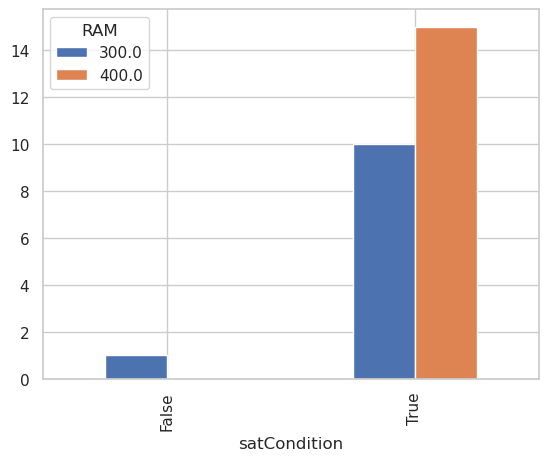

In [111]:
df_over.groupby('RAM').value_counts().unstack(0).plot.bar()

<Axes: xlabel='satCondition'>

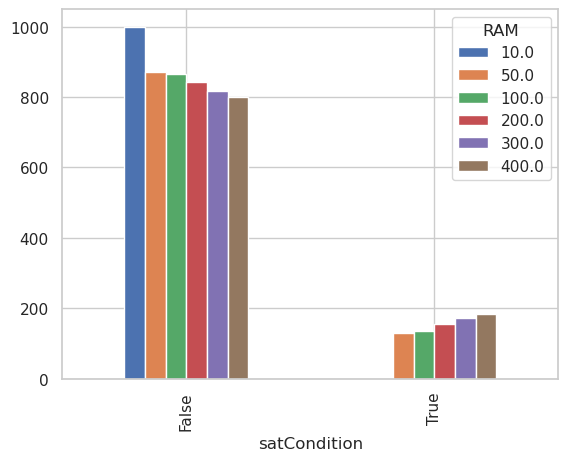

In [112]:
df_under = df_28[df_28['estimate'] <= df_28['intersectionSizeOfR']][['RAM','satCondition']]
df_under['RAM'] = df_under['RAM']/(8e6)
df_under.groupby('RAM').value_counts().unstack(0).plot.bar()

In [113]:
df_28['parameters']

0        [3, 46, 0, 0]
1        [3, 46, 0, 0]
2        [3, 46, 0, 0]
3        [3, 46, 0, 0]
4        [3, 46, 0, 0]
             ...      
5995    [3, 742, 0, 0]
5996    [3, 742, 0, 0]
5997    [3, 742, 0, 0]
5998    [3, 742, 0, 0]
5999    [3, 742, 0, 0]
Name: parameters, Length: 6000, dtype: object

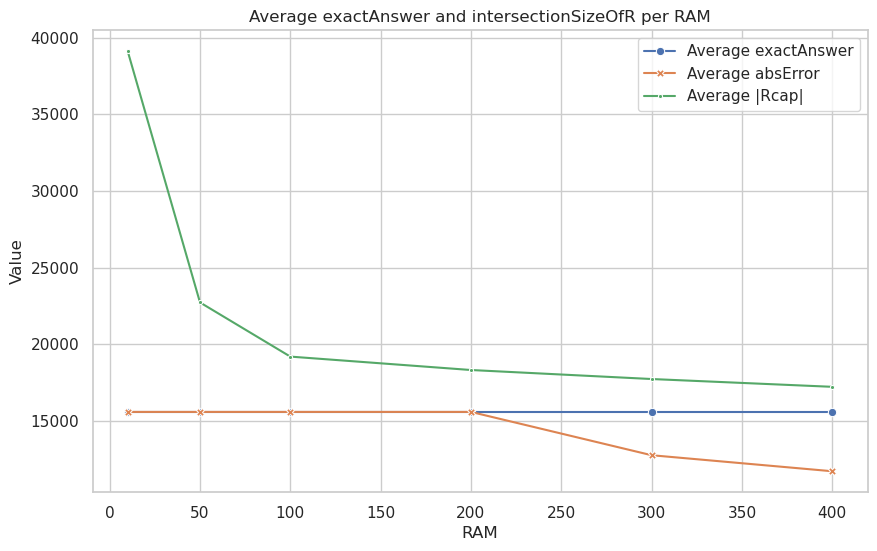

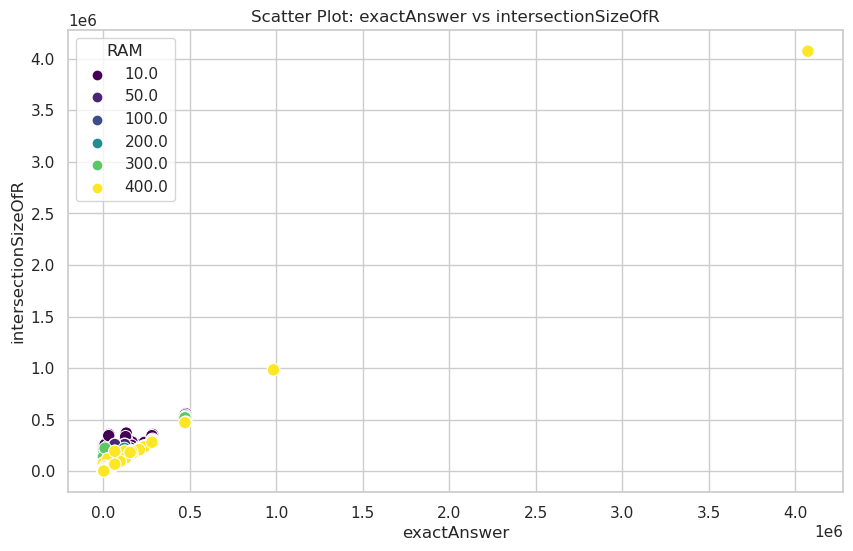

In [114]:
#plot_estimate(df_7, 'exactAnswer', 'intersectionSizeOfR', 'estimate')
df_28['RAM'] = df_28['RAM']/(8e6)
plot_estimate(df_28, 'exactAnswer', 'intersectionSizeOfR', 'absError')

In [46]:
df_n1 = df1[df1['noiseUpdates'] == df1['noiseUpdates'].min()]
df_n2 = df1[df1['noiseUpdates'] == df1['noiseUpdates'].max()]
df = df_28
df_sat = df[df['satCondition']]
df_not_sat = df[~df['satCondition']]


def stats(df):
    df['error'] = df['estimate'] - df['exactAnswer']
    df_wo_p_1 = df[df['numPredicates']>=1]
    
    df_g = df_wo_p_1.groupby('RAM').mean(['error', 'absError'])
    print(df_g['error'])
    print(df_g['absError'])
    
stats(df)
stats(df_sat)
stats(df_not_sat)

NameError: name 'df1' is not defined

In [87]:
df_n1 = df1[df1['noiseUpdates'] == df1['noiseUpdates'].min()]
df_n2 = df1[df1['noiseUpdates'] == df1['noiseUpdates'].max()]

df_sat = df[df['satCondition']]
df_not_sat = df[~df['satCondition']]


def stats(df):
    df['error'] = df['estimate'] - df['exactAnswer']
    df_wo_p_1 = df[df['numPredicates']>=1]
    
    df_g = df_wo_p_1.groupby('RAM').mean(['error', 'absError'])
    print(df_g['error'])
    print(df_g['absError'])
    
stats(df)
stats(df_sat)
stats(df_not_sat)

RAM
80000000       38591.761
400000000      81918.688
800000000     104915.789
1600000000    125334.561
2400000000    135828.251
3200000000    143870.078
4000000000    139043.203
Name: error, dtype: float64
RAM
80000000       54952.495
400000000      88467.114
800000000     110564.875
1600000000    130703.983
2400000000    137859.861
3200000000    145419.300
4000000000    140447.925
Name: absError, dtype: float64
RAM
400000000     411383.757812
800000000     484537.820312
1600000000    494586.428571
2400000000    413432.418685
3200000000    340553.283163
4000000000    289814.056054
Name: error, dtype: float64
RAM
400000000     427907.742188
800000000     494129.929688
1600000000    505476.428571
2400000000    413452.896194
3200000000    340553.283163
4000000000    290636.679372
Name: absError, dtype: float64
RAM
80000000      38591.761000
400000000     33556.842890
800000000     49191.454128
1600000000    31284.210790
2400000000    22990.551336
3200000000    17061.169408
4000000000    

/tmp/ipykernel_12397/1482923098.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['error'] = df['estimate'] - df['exactAnswer']
/tmp/ipykernel_12397/1482923098.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['error'] = df['estimate'] - df['exactAnswer']


In [10]:
df1[['queryText','exactAnswer','unionSize','estimate','condition']]

,queryText,exactAnswer,unionSize,estimate,condition
0,"ipDstHost=235229,",393722,393722,273720,1.19040
1,"ipDstNet=54223,",1158035,1158035,1071048,1.19040
2,"ipDstNet=54223, ipDstHost=235229,",393715,1158035,535524,2.38080
3,"ipSrcHost=125193,",122932,122932,136872,1.19040
4,"ipSrcHost=125193, ipDstHost=235229,",120744,122932,0,2.38080
...,...,...,...,...,...
5995,"ipProto=6, ipSrcHost=2985, ipDstNet=42141,",4818,21611741,0,0.05952
5996,"ipProto=6, ipSrcHost=2985, ipDstNet=42141, ipD...",4818,21611741,0,0.07936
5997,"ipProto=6, ipSrcNet=24541,",25677,21611741,0,0.03968
5998,"ipProto=6, ipSrcNet=24541, ipDstHost=9659,",4818,21611741,0,0.05952


In [11]:
def condition_stats(df):
    df_sat = df[df['satCondition']]
    df_not_sat = df[~df['satCondition']]
    
    print("Queries satisfying condition {} and not satisying {}".format(len(df_sat.index), len(df_not_sat.index)))
    
    # Per RAM value
    rams = df['RAM'].unique()
    print("streamsize {}".format(df['totalStreamSize'].unique()))
    for i in rams:
        dfr = df[df['RAM'] == i]
        df_sat = dfr[dfr['satCondition']]
        df_not_sat = dfr[~dfr['satCondition']]
        print("RAM = {} has {} satisfying and {} non-satisfying queries".format(i/(8e6), len(df_sat.index), len(df_not_sat.index)))
        num_zero_sat = df_sat[df_sat['estimate'] == 0]
        num_zero_not_sat = df_not_sat[df_not_sat['estimate'] == 0]
        print("Zero estimates sat = {}, zero estimates not sat = {}".format(len(num_zero_sat.index), len(num_zero_not_sat.index)))
        df_not_sat['exactAnswer'].plot()
        print("\n")

Queries satisfying condition 1427 and not satisying 4573
streamsize [26874162]
RAM = 10.0 has 0 satisfying and 1000 non-satisfying queries
Zero estimates sat = 0, zero estimates not sat = 899


RAM = 50.0 has 210 satisfying and 790 non-satisfying queries
Zero estimates sat = 64, zero estimates not sat = 740


RAM = 100.0 has 249 satisfying and 751 non-satisfying queries
Zero estimates sat = 94, zero estimates not sat = 694


RAM = 200.0 has 284 satisfying and 716 non-satisfying queries
Zero estimates sat = 93, zero estimates not sat = 626


RAM = 400.0 has 332 satisfying and 668 non-satisfying queries
Zero estimates sat = 111, zero estimates not sat = 540


RAM = 600.0 has 352 satisfying and 648 non-satisfying queries
Zero estimates sat = 99, zero estimates not sat = 520




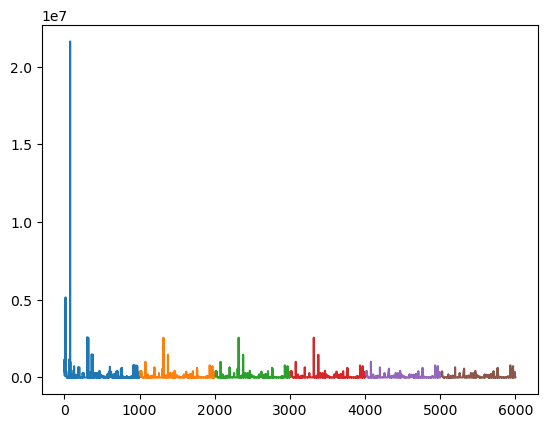

In [12]:
condition_stats(df1)

##### From stats we see that with more memory, more conditions are satisfied as expected. When we plot the exactAnswer size per ram size we see that the anser size of queries that have a 0 prediction slinks.

In [146]:
def plot_err_dist(df, p):
    df = df[df['numPredicates'] == p]
    print("{} Predicates".format(p))
    data = [df[df['ram'] == group]['testErr'] for group in df['ram'].unique()]

    # Plotting boxplots
    plt.boxplot(data, labels=df['ram'].unique())
    #plt.plot(data, labels=df['ram'].unique())
    plt.xlabel('RAM (MB)')
    plt.ylabel('testerr')
    plt.title('Distributions of estimate per ram for {}'.format(p))
    plt.show()

1 Predicates


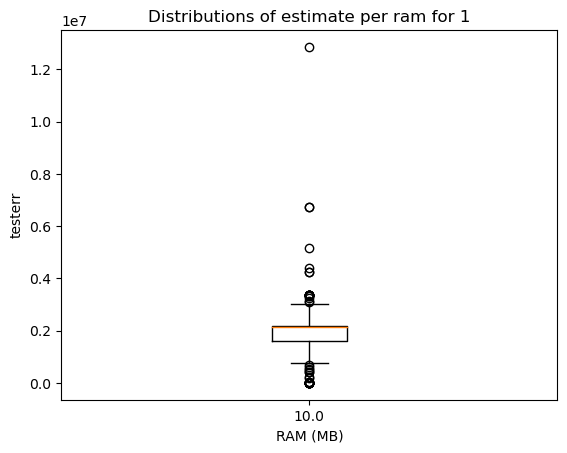

2 Predicates


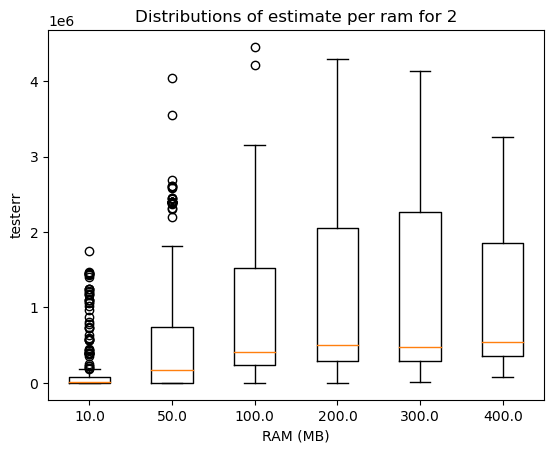

3 Predicates


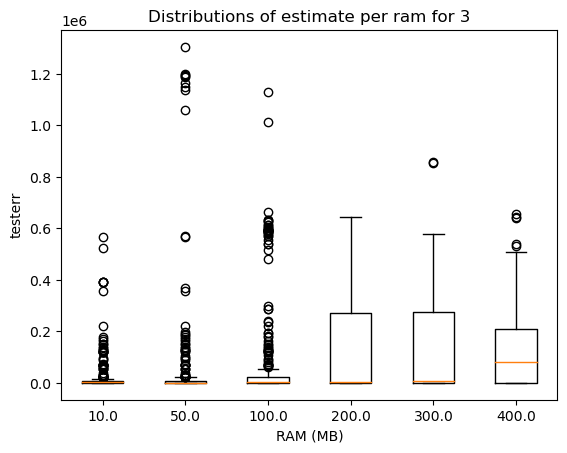

4 Predicates


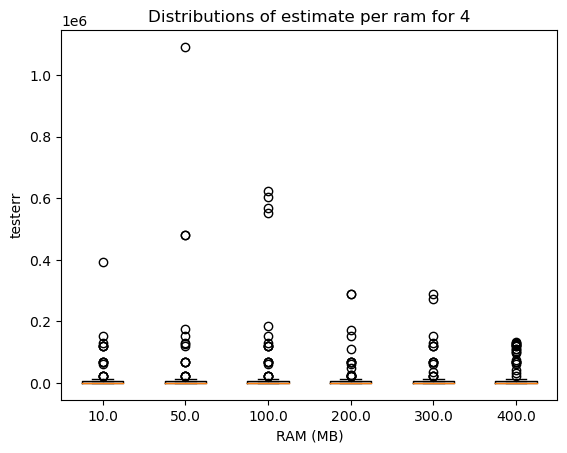

5 Predicates


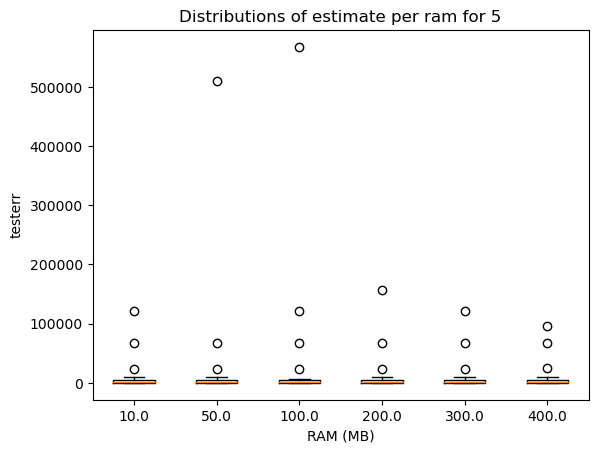

In [155]:

df['ram'] = df['RAM']/(8e6)
df['testErr'] = abs(df['estimate'] - df['exactAnswer'])
df_not_zero = df[df['estimate'] != 0]
df_zero = df[df['estimate'] == 0]
df_sat = df[~df['satCondition']]
for i in df['numPredicates'].unique():
    plot_err_dist(df_sat,i)
    


In [156]:
df_wo_p_1 = df_sat[df_sat['numPredicates']>1]
df_g = df_wo_p_1.groupby('RAM').mean('testErr')
df_g['testErr']

RAM
80000000       69461.521789
400000000     209734.988608
800000000     305290.157124
1600000000    395658.745810
2400000000    421768.991304
3200000000    393885.432635
Name: testErr, dtype: float64

# Plots below here until the dotted line are all computed with exact union, so not using an estimate of the union in their intersection estimation.

In [149]:
df10 = df[df['RAM'] == df['RAM'].min()]
df400 = df[df['RAM'] == df['RAM'].max()]

In [128]:
df.groupby(['RAM']).mean('epsError')

,totalStreamSize,numAttributes,memUsageDataset,Avg Update Time,memUsageSynopsis,numAttributesInWorkload,queryID,numPredicates,exactAnswer,estimate,...,relError,epsError,withinThreshold,estTime,streamSizeAfterDeletes,unionSize,condition,satCondition,ram,testErr
RAM,,,,,,,,,,,,,,,,,,,,,
80000000,5077343.0,11.0,974849856.0,23.0,7.999488e+07,5.0,499.5,2.644,15591.466,235182.875,...,6142.238230,0.044949,0.819,0.023,5077343.0,1633141.686,3.147418,0.000,10.0,228222.285
400000000,5077343.0,11.0,974849856.0,85.0,3.999744e+08,5.0,499.5,2.644,15591.466,288297.313,...,9196.643581,0.054128,0.781,0.085,5077343.0,1633141.686,0.629484,0.225,50.0,274826.449
800000000,5077343.0,11.0,974849856.0,158.0,7.999488e+08,5.0,499.5,2.644,15591.466,244453.958,...,5706.872861,0.045822,0.817,0.158,5077343.0,1633141.686,0.314742,0.263,100.0,232653.212
1600000000,5077343.0,11.0,974849856.0,310.0,1.599898e+09,5.0,499.5,2.644,15591.466,260269.533,...,6368.802201,0.048531,0.793,0.310,5077343.0,1633141.686,0.157371,0.321,200.0,246406.643
2400000000,5077343.0,11.0,974849856.0,553.0,2.399846e+09,5.0,499.5,2.644,15591.466,236898.290,...,5924.056463,0.044055,0.816,0.553,5077343.0,1633141.686,0.104914,0.342,300.0,223682.312
3200000000,5077343.0,11.0,974849856.0,701.0,3.199795e+09,5.0,499.5,2.644,15591.466,265910.932,...,6399.549113,0.049340,0.787,0.700,5077343.0,1633141.686,0.078685,0.352,400.0,250515.952


## Estimate
### Problem is that we have a lot of estimate = 0
#### Other statistic: we have 371 queries without any witness of an empty or singleton bucket at the specified index.
#### We have 511 queries without witness of a singleton bucket, that do have a witness of an empty one.
#### So 118 queries have a witness and thus estimate > 0.

# All for 400 MB

In [72]:
df.columns

Index(['totalStreamSize', 'numAttributes', 'memUsageDataset', 'RAM', 'setting',
       'Avg Update Time', 'memUsageSynopsis', 'parameters',
       'numAttributesInWorkload', 'queryID', 'numPredicates', 'exactAnswer',
       'estimate', 'absError', 'relError', 'epsError', 'withinThreshold',
       'estTime', 'queryText', 'streamSizeAfterDeletes', 'unionSize'],
      dtype='object')

In [74]:
df400['parameters'].unique()

array(['[3, 7, 0, 0]'], dtype=object)

In [75]:
df

,totalStreamSize,numAttributes,memUsageDataset,RAM,setting,Avg Update Time,memUsageSynopsis,parameters,numAttributesInWorkload,queryID,...,exactAnswer,estimate,absError,relError,epsError,withinThreshold,estTime,queryText,streamSizeAfterDeletes,unionSize
0,5077343,11,974849856,80000000,OmniSketch,23,79994880,"[3, 7, 0, 0]",5,0,...,75313,273720,198407,2.634432,0.039077,True,0,"ipDstHost=235229,",5077343,75313
1,5077343,11,974849856,80000000,OmniSketch,23,79994880,"[3, 7, 0, 0]",5,1,...,213209,267768,54559,0.255894,0.010746,True,0,"ipDstNet=54223,",5077343,213209
2,5077343,11,974849856,80000000,OmniSketch,23,79994880,"[3, 7, 0, 0]",5,2,...,75313,0,75313,1.000000,0.014833,True,0,"ipDstNet=54223, ipDstHost=235229,",5077343,213209
3,5077343,11,974849856,80000000,OmniSketch,23,79994880,"[3, 7, 0, 0]",5,3,...,24641,840120,815479,33.094396,0.160611,False,0,"ipSrcHost=125193,",5077343,24641
4,5077343,11,974849856,80000000,OmniSketch,23,79994880,"[3, 7, 0, 0]",5,4,...,24228,0,24228,1.000000,0.004772,True,0,"ipSrcHost=125193, ipDstHost=235229,",5077343,24641
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,5077343,11,974849856,3200000000,OmniSketch,795,3199795200,"[3, 7, 0, 0]",5,995,...,1429,66571,65142,45.585724,0.012830,True,0,"ipProto=6, ipSrcHost=2985, ipDstNet=42141,",5077343,4072645
5996,5077343,11,974849856,3200000000,OmniSketch,795,3199795200,"[3, 7, 0, 0]",5,996,...,1429,0,1429,1.000000,0.000281,True,1,"ipProto=6, ipSrcHost=2985, ipDstNet=42141, ipD...",5077343,4072645
5997,5077343,11,974849856,3200000000,OmniSketch,795,3199795200,"[3, 7, 0, 0]",5,997,...,3705,479317,475612,128.370310,0.093673,True,1,"ipProto=6, ipSrcNet=24541,",5077343,4072645
5998,5077343,11,974849856,3200000000,OmniSketch,795,3199795200,"[3, 7, 0, 0]",5,998,...,1429,61625,60196,42.124563,0.011856,True,0,"ipProto=6, ipSrcNet=24541, ipDstHost=9659,",5077343,4072645


In [41]:
df = df[df['RAM'] == 400*8e6]

In [42]:
df['estimate'].value_counts()

0         327
73619      18
73613      15
595680     14
720480     14
         ... 
134400      1
169159      1
78800       1
167514      1
498785      1
Name: estimate, Length: 406, dtype: int64

#todo : add plot for query satisfying the storage/witness constraint and without the constraint.
For tomorrow, next steps are to:
- Analyze why we still have this many zero predictions
- Analyze whether error becomes better with more MB
- Make plan for what's next: test with deletes

Statistics:
1000 queries
N = 26874162, so 26M
Size of omnisketch is 6348800000 bits, is 793.6 MB
We have 1000 repetitions of 2lhs in every cell, each repetition has different hash functions. In cell A, repetition 1 has same hash functions as it does in cell B.
Testing all with unique hash functions 


<Axes: >

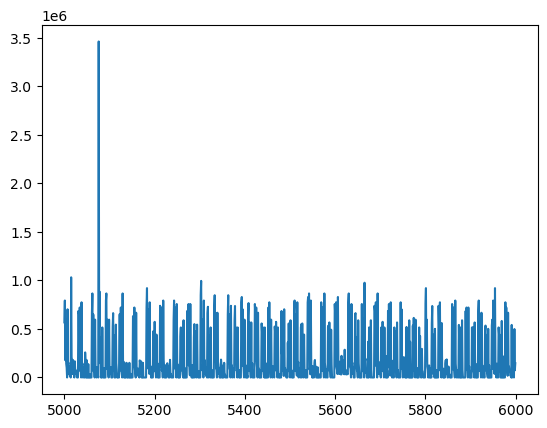

In [43]:
df['estimate'].plot()

## Estimate per number of predicates
### Some outliers at lower # predicates

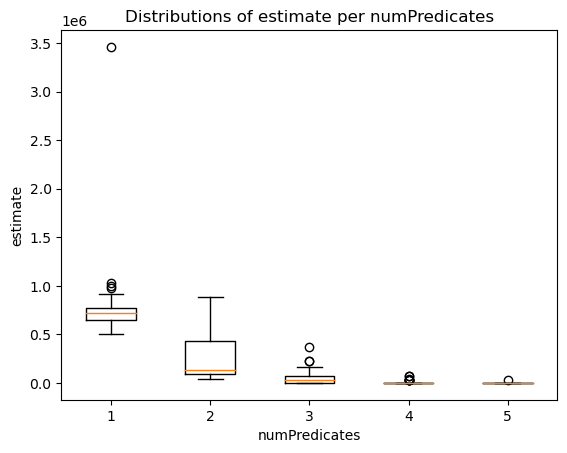

In [44]:
data = [df[df['numPredicates'] == group]['estimate'] for group in df['numPredicates'].unique()]

# Plotting boxplots
plt.boxplot(data, labels=df['numPredicates'].unique())
plt.xlabel('numPredicates')
plt.ylabel('estimate')
plt.title('Distributions of estimate per numPredicates')
plt.show()

#### Plot without outliers

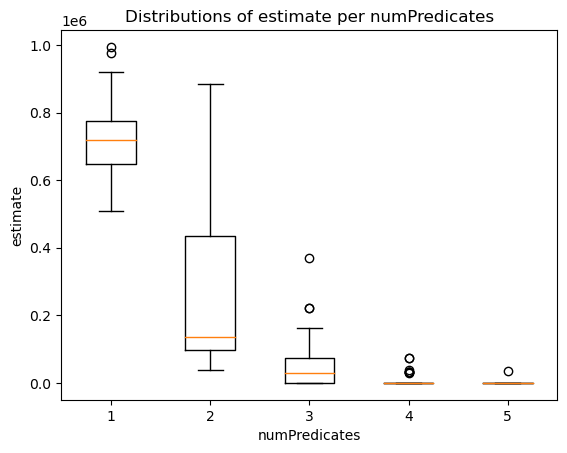

In [46]:
df3 = df[df['estimate']<1e6]

data_wo_outliers = [df3[df3['numPredicates'] == group]['estimate'] for group in df3['numPredicates'].unique()]

# Plotting boxplots
plt.boxplot(data_wo_outliers, labels=df['numPredicates'].unique())
plt.xlabel('numPredicates')
plt.ylabel('estimate')
plt.title('Distributions of estimate per numPredicates')
plt.show()

## Estimate per union size:

### All union sizes (and all estimations) are based on the actual union size.

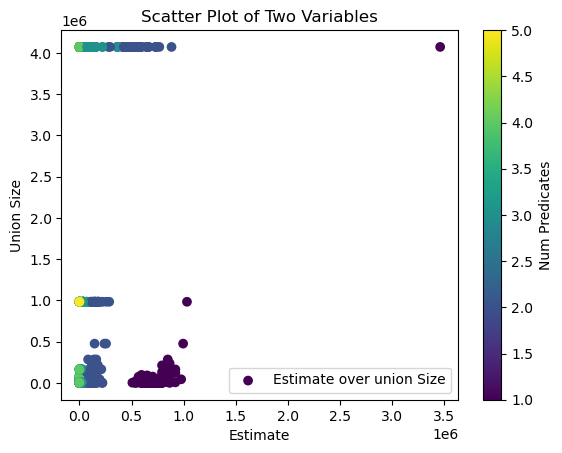

In [45]:
# Assuming df['numPredicates'] contains categorical values
# You can adjust cmap based on your preference
cmap = plt.get_cmap('viridis')

# Plotting the data with colors based on df['numPredicates']
scatter = plt.scatter(df['estimate'], df['unionSize'], c=df['numPredicates'], cmap=cmap, label='Estimate over union Size')

# Adding labels and title
plt.xlabel('Estimate')
plt.ylabel('Union Size')
plt.title('Scatter Plot of Two Variables')

# Displaying the legend (optional)
plt.legend()

# Adding colorbar to show the mapping of colors to values
cbar = plt.colorbar(scatter)
cbar.set_label('Num Predicates')

# Displaying the plot
plt.show()

### Without the high union sizes:

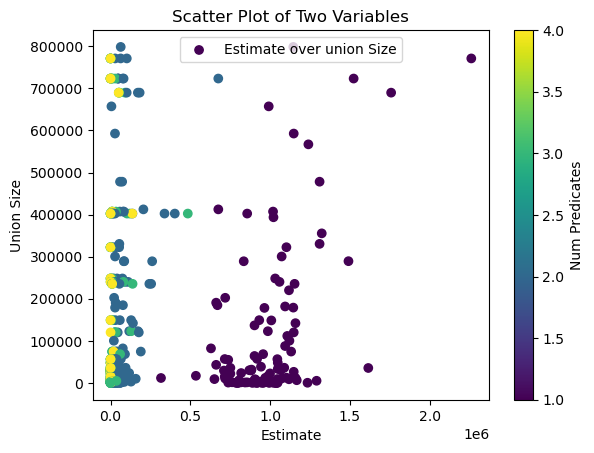

In [29]:
# Plotting the data
df1 = df[df['unionSize'] < 1e6]
# Assuming df['numPredicates'] contains categorical values
# You can adjust cmap based on your preference
cmap = plt.get_cmap('viridis')

# Plotting the data with colors based on df['numPredicates']
scatter = plt.scatter(df1['estimate'], df1['unionSize'], c=df1['numPredicates'], cmap=cmap, label='Estimate over union Size')

# Adding labels and title
plt.xlabel('Estimate')
plt.ylabel('Union Size')
plt.title('Scatter Plot of Two Variables')

# Displaying the legend (optional)
plt.legend()

# Adding colorbar to show the mapping of colors to values
cbar = plt.colorbar(scatter)
cbar.set_label('Num Predicates')

# Displaying the plot
plt.show()

In [11]:
df['unionSize']

0        75313
1       213209
2       213209
3        24641
4        24641
        ...   
995    4072645
996    4072645
997    4072645
998    4072645
999    4072645
Name: unionSize, Length: 1000, dtype: int64

### We see from these plots that there is no immediate link between union size and whether they have an estimate

## Error per number of predicates

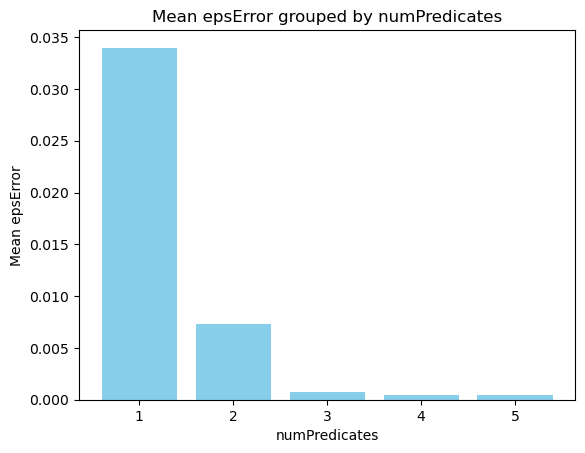

In [12]:
grouped_df = df.groupby('numPredicates')['epsError'].mean().reset_index()

# Plotting
plt.bar(grouped_df['numPredicates'], grouped_df['epsError'], color='skyblue')
plt.xlabel('numPredicates')
plt.ylabel('Mean epsError')
plt.title('Mean epsError grouped by numPredicates')
plt.show()

## Estimate over answer size

<Axes: >

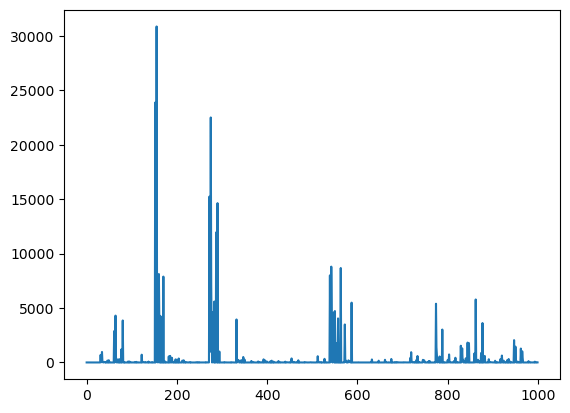

In [13]:
(df['estimate']/df['exactAnswer']).plot()


## Exact Answer per number of predicates

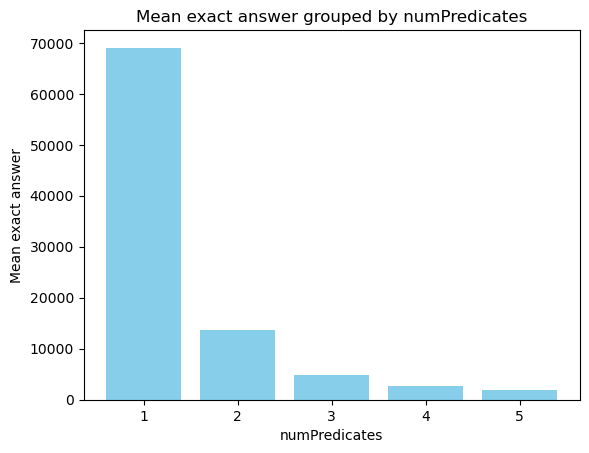

In [14]:
grouped_df = df.groupby('numPredicates')['exactAnswer'].mean().reset_index()

# Plotting
plt.bar(grouped_df['numPredicates'], grouped_df['exactAnswer'], color='skyblue')
plt.xlabel('numPredicates')
plt.ylabel('Mean exact answer')
plt.title('Mean exact answer grouped by numPredicates')
plt.show()

# .. ...................................................................................................................................

# Plots with estimated union

<Axes: >

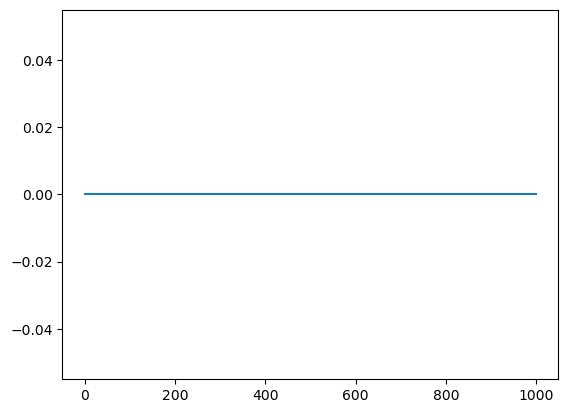

In [15]:
df2 = pd.read_csv("/home/wieger/Documents/Research/Omnisketch/omni/output/pointQueries/CAIDA/results_Test Two LHS_CAIDA_2024-01-08 16:57:56_Rep2.csv")
df2['estimate'].plot()

## So all estimates are zero.
### All 1000 queries have no witness of empty or singleton bucket